# Crime Stats Eploratory Data Analysis

## Executive Summary:

### Import Libraries:

In [83]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as plt
import seaborn as sns
import fiona
from shapely import Point
from shapely.wkt import loads
from scipy import stats

### Load Data:

In [3]:
data = ('cleanData')
cd = os.path.abspath('')
cwd = os.path.abspath(os.path.join(cd,data))

forces = pd.read_csv(cwd+'\\'+'forces_combined_clean.csv')
forces = gpd.GeoDataFrame(forces)
forces['geometry'] = forces['geometry'].apply(loads)
forces = forces.set_geometry('geometry')
forces = forces.set_crs('EPSG:4326')

pfa_boundaries = pd.read_csv(cwd+'\\'+'boundaries_combined_clean.csv')
pfa_boundaries = gpd.GeoDataFrame(pfa_boundaries)
pfa_boundaries['geometry'] = pfa_boundaries['geometry'].apply(loads)
pfa_boundaries = pfa_boundaries.set_geometry('geometry')
pfa_boundaries = pfa_boundaries.set_crs('EPSG:4326')

#LSOA_boundaries are in British National Grid coordinates so need more steps to be reprojected:
lsoa_boundaries = pd.read_csv(cwd+'\\'+'lsoa_boundaries_clean.csv')
lsoa_boundaries = gpd.GeoDataFrame(lsoa_boundaries)
lsoa_boundaries['geometry'] = lsoa_boundaries['geometry'].apply(loads)
lsoa_boundaries = lsoa_boundaries.set_geometry('geometry')
lsoa_boundaries = lsoa_boundaries.set_crs('EPSG:27700',allow_override=True)
lsoa_boundaries = lsoa_boundaries.to_crs(pfa_boundaries.crs)

lsoa_pop = pd.read_csv(cwd+'\\'+'lsoa_combined_clean.csv')
lsoa_pop = pd.DataFrame(lsoa_pop)

pfa_pop = pd.read_csv(cwd+'\\'+'pfa_pop_clean.csv')
pfa_pop = pd.DataFrame(pfa_pop)

In [ ]:
for columns in for

In [65]:
pfa_colors = {
    'Essex': '#E63946',
    'Hertfordshire': '#2196F3',
    'Kent': '#FF9800',
    'Surrey': '#4CAF50',
}

## Crime Heatmap

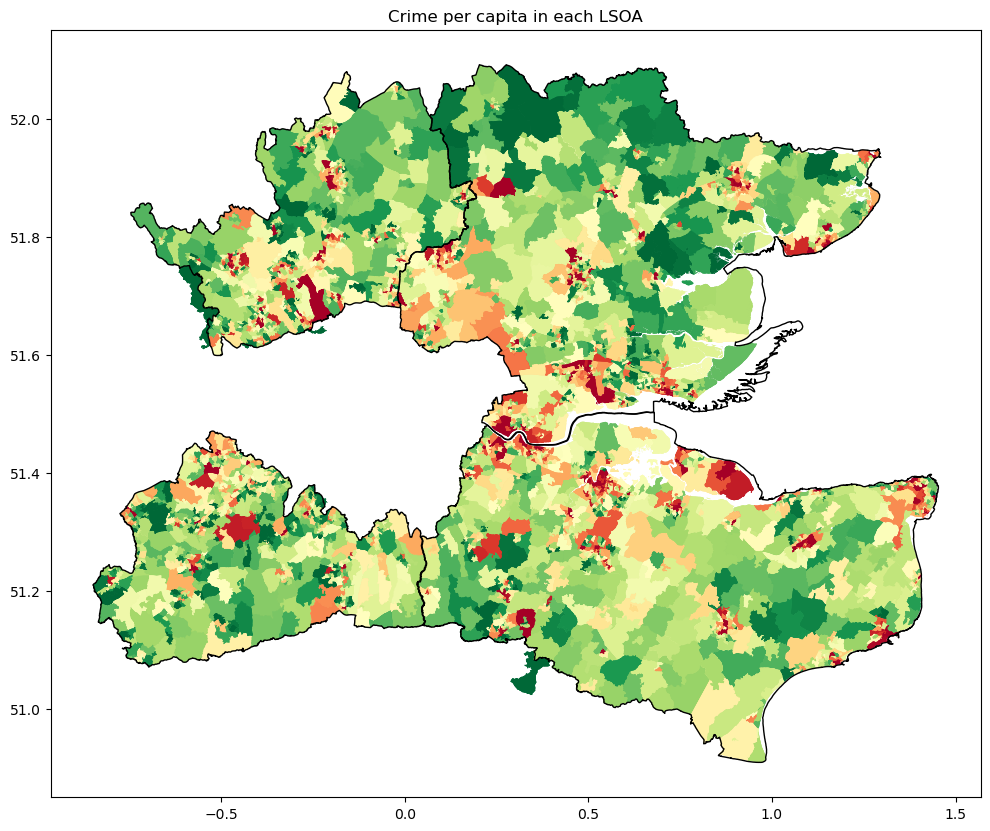

In [186]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

lsoa_boundariesa = lsoa_boundaries.merge(lsoa_pop[['LSOA 2021 Code','Total']],left_on='LSOA21CD',right_on='LSOA 2021 Code',how='left')
sj = forces.sjoin(lsoa_boundariesa,how='left',predicate='within')
inside = sj.groupby('index_right').size().rename('number_inside')

lsoa_boundariesa = lsoa_boundariesa.copy()
lsoa_boundariesa['number_inside'] = lsoa_boundariesa.index.map(inside).fillna(0)
lsoa_boundariesa['crime_pc'] = lsoa_boundariesa['number_inside']/lsoa_boundariesa['Total'].replace(0, float('nan'))

fig,ax = plt.subplots(figsize=(12,12))
lsoa_boundariesa.plot(ax=ax,column='crime_pc',cmap='RdYlGn_r',legend=False,norm=LogNorm(vmin=lsoa_boundariesa['crime_pc'].quantile(0.05),vmax=lsoa_boundariesa['crime_pc'].quantile(0.95)))
pfa_boundaries['geometry'].plot(ax=ax,color='none',edgecolor='black',zorder=3)
plt.title('Crime per capita in each LSOA')
plt.show()

Essex: stat=3198.415, p=0.000 — NOT normal
Hertfordshire: stat=1472.053, p=0.000 — NOT normal
Kent: stat=3254.501, p=0.000 — NOT normal
Surrey: stat=1893.862, p=0.000 — NOT normal
Levene's test: stat=40.219, p=0.000


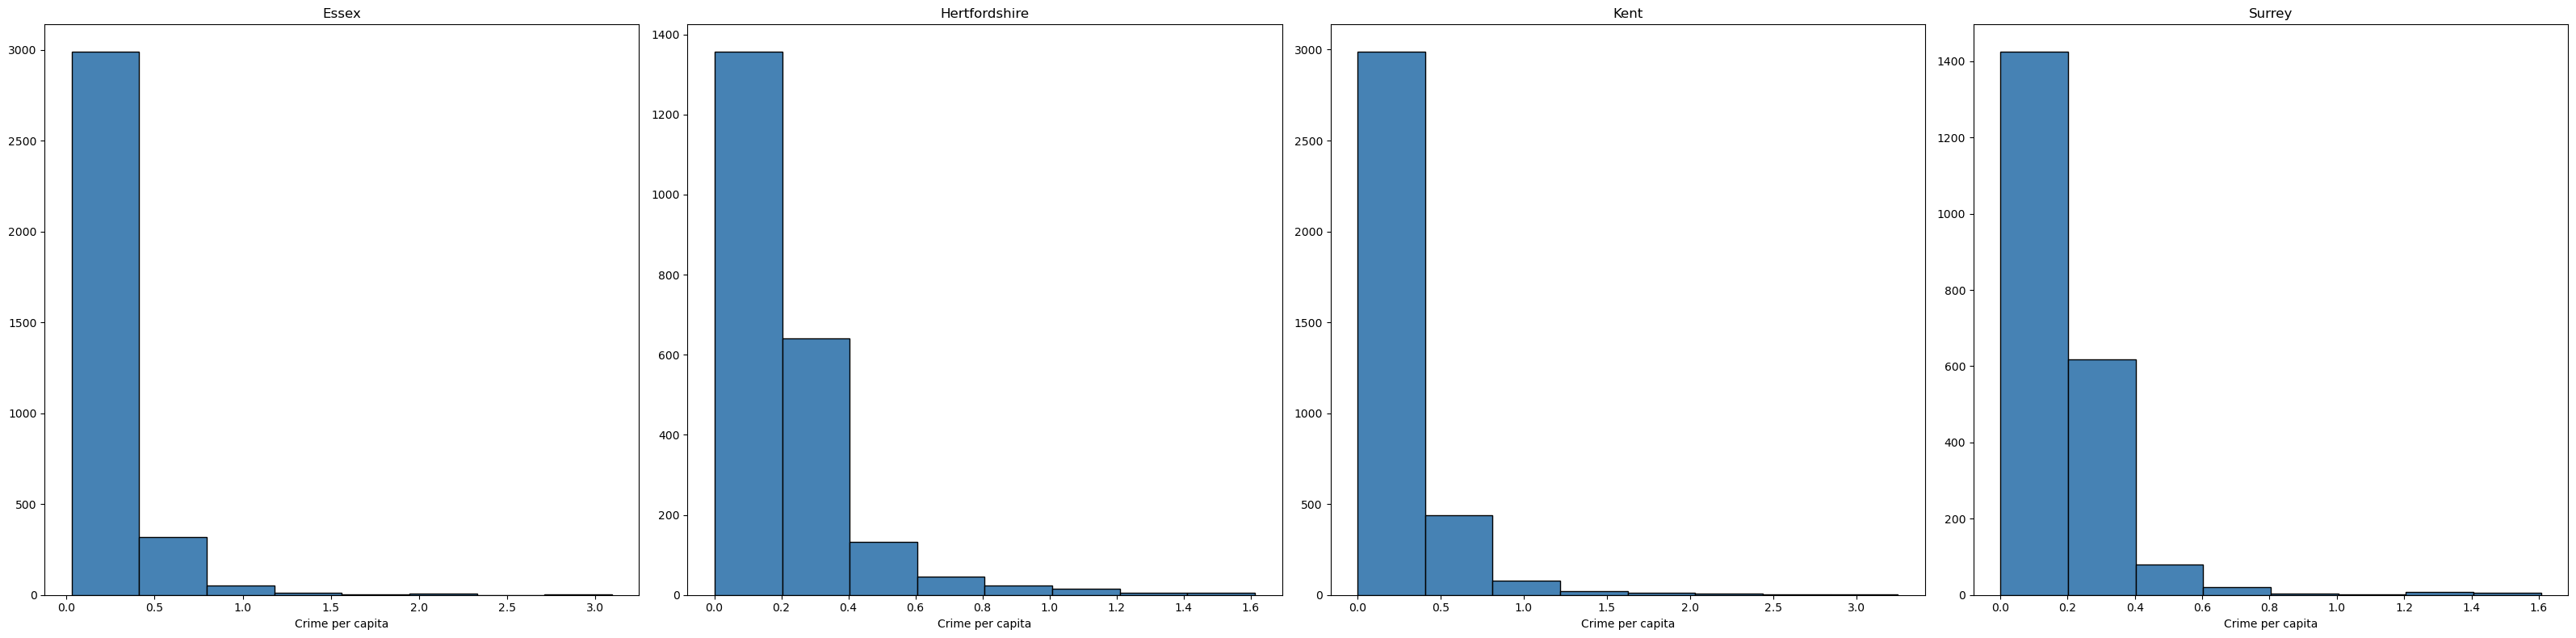

In [154]:
#Testing the sinificance of the results

# Count of crimes per each LSOA
lsoa_crimes = forces.groupby(['LSOA code','LSOA name','PFA']).size().reset_index(name='crime_count')

# Merge with LSOA boundaries
sig_df = lsoa_boundariesa.merge(lsoa_crimes, left_on='LSOA 2021 Code', right_on='LSOA code', how='left')
sig_df['crime_count'] = sig_df['crime_count'].fillna(0)

# Calculate crime per capita
sig_df['crime_pc'] = sig_df['crime_count'] / sig_df['Total']

#Check Assumptions
#Normality
#Using D'Agostino-Pearson for a large sample
for pfa, group in sig_df.groupby('PFA'):
    stat, p = stats.normaltest(group['crime_pc'].dropna())
    print(f"{pfa}: stat={stat:.3f}, p={p:.3f} — {'normal' if p > 0.05 else 'NOT normal'}")
#None of them are normal, suggesting that high crime per capita is concentrated in a small number of LSOAs

#Equal variances
groups = [group['crime_pc'].values for _, group in sig_df.groupby('PFA')]
stat, p = stats.levene(*groups)
print(f"Levene's test: stat={stat:.3f}, p={p:.3f}")

import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(32, 8))

for i, (pfa, group) in enumerate(sig_df.groupby('PFA')):
    # Histogram
    axes[i].hist(group['crime_pc'], bins=8, color='steelblue', edgecolor='black')
    axes[i].set_title(pfa)
    axes[i].set_xlabel('Crime per capita')

plt.tight_layout()
plt.show()

#Histograms corroborate the normality check

In [150]:
#Since data is not normal, the Kruskal-Wallis test was used
stat, p = stats.kruskal(*groups)
print("Kruskal-Wallis: H=", round(stat, 3), "p=", round(p, 3))

# Dunn's post-hoc test
import scikit_posthocs as sp
dunn = sp.posthoc_dunn(sig_df, val_col='crime_pc', group_col='PFA', p_adjust='bonferroni')
print(dunn)


Kruskal-Wallis: H= 277.352 p= 0.0
                      Essex  Hertfordshire          Kent        Surrey
Essex          1.000000e+00   2.344394e-02  1.658791e-12  4.665116e-22
Hertfordshire  2.344394e-02   1.000000e+00  4.872033e-20  1.740835e-09
Kent           1.658791e-12   4.872033e-20  1.000000e+00  4.896369e-59
Surrey         4.665116e-22   1.740835e-09  4.896369e-59  1.000000e+00


C:\Users\andre\AppData\Local\Temp\ipykernel_4868\4109386250.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10 = lsoa_avg.groupby('PFA').apply(


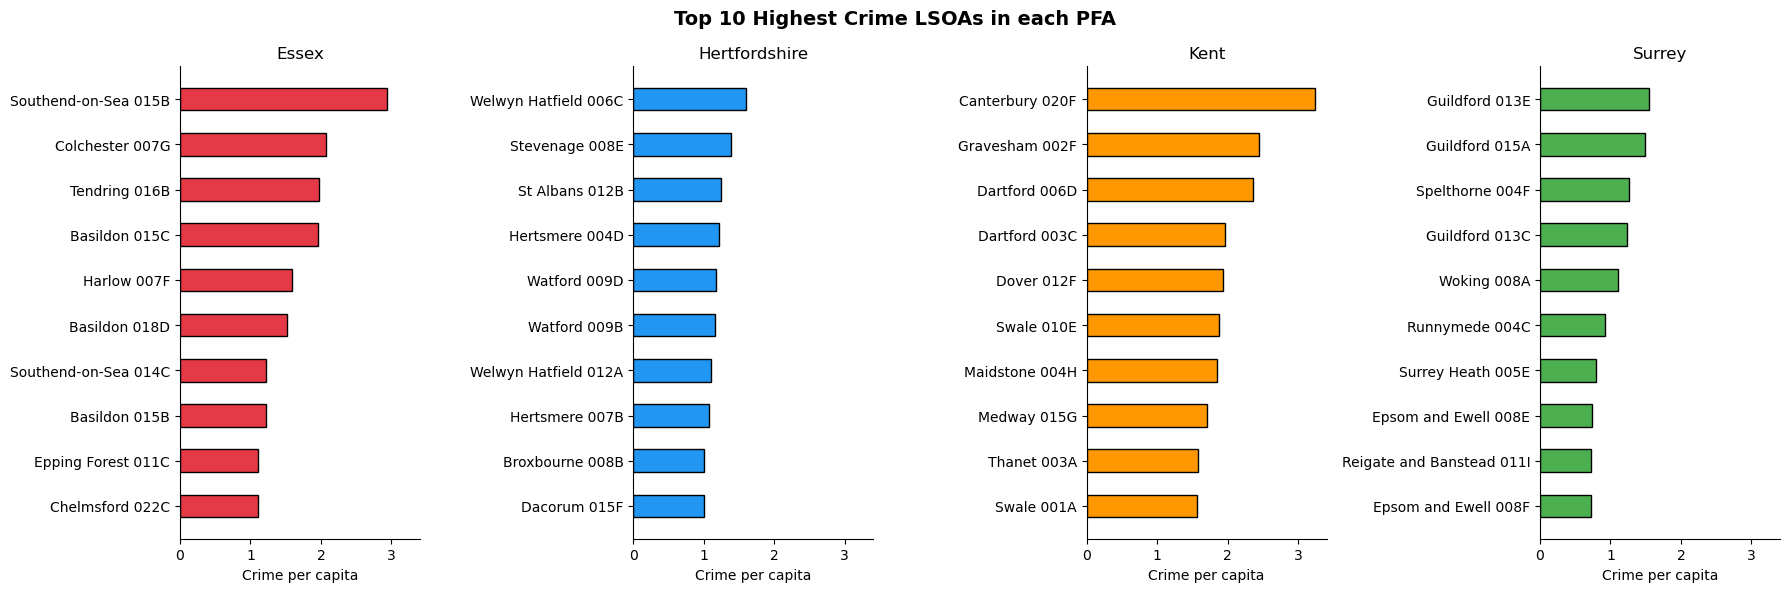

In [178]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6),sharex=True)
pfas = ['Essex', 'Hertfordshire', 'Kent', 'Surrey']

lsoa_avg = sig_df.groupby(['LSOA 2021 Code', 'LSOA21NM', 'PFA'])['crime_pc'].mean().reset_index()

top10 = lsoa_avg.groupby('PFA').apply(
    lambda x: x.nlargest(10, 'crime_pc')
).reset_index(drop=True)

for i, pfa in enumerate(pfas):
    pfa_data = top10[top10['PFA'] == pfa].sort_values('crime_pc')
    axes[i].barh(pfa_data['LSOA21NM'], pfa_data['crime_pc'],
                 height=0.5,
                 color=pfa_colors[pfa], edgecolor='black')
    axes[i].set_title(pfa)
    axes[i].set_xlabel('Crime per capita')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Top 10 Highest Crime LSOAs in each PFA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_4868\2069010461.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bot10 = lsoa_avg.groupby('PFA').apply(


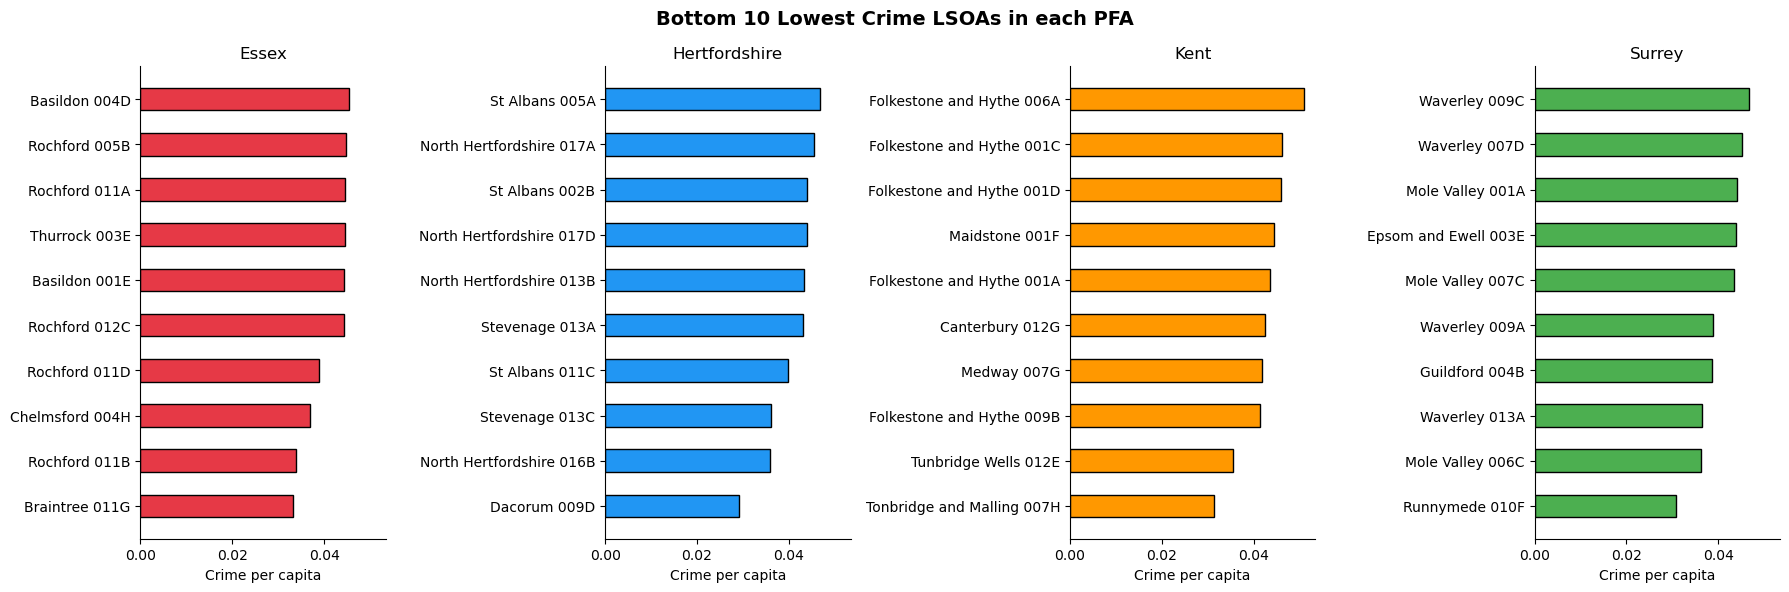

In [197]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6),sharex=True)
pfas = ['Essex', 'Hertfordshire', 'Kent', 'Surrey']

lsoa_avg = sig_df.groupby(['LSOA 2021 Code', 'LSOA21NM', 'PFA'])['crime_pc'].mean().reset_index()

#Filtering out the outliers:
lsoa_avg = lsoa_avg[lsoa_avg['crime_pc'] > 0.01]

bot10 = lsoa_avg.groupby('PFA').apply(
    lambda x: x.nsmallest(10, 'crime_pc')
).reset_index(drop=True)

for i, pfa in enumerate(pfas):
    pfa_data = bot10[bot10['PFA'] == pfa].sort_values('crime_pc')
    axes[i].barh(pfa_data['LSOA21NM'], pfa_data['crime_pc'],
                 height=0.5,
                 color=pfa_colors[pfa], edgecolor='black')
    axes[i].set_title(pfa)
    axes[i].set_xlabel('Crime per capita')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Bottom 10 Lowest Crime LSOAs in each PFA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

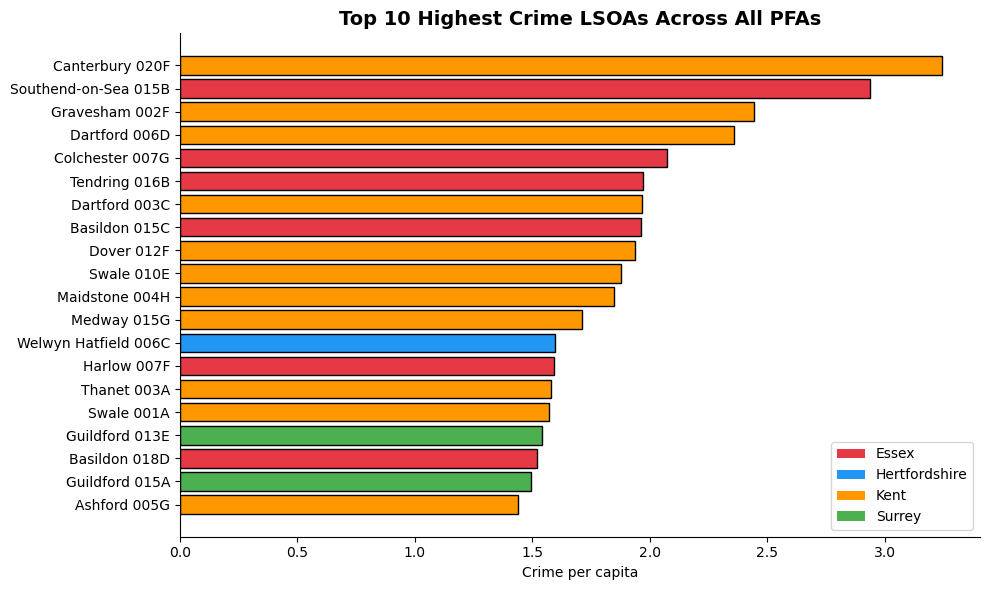

In [179]:
top20_all = lsoa_avg.nlargest(20, 'crime_pc').sort_values('crime_pc')

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors_list = [pfa_colors[pfa] for pfa in top10_all['PFA']]

ax.barh(top20_all['LSOA21NM'], top20_all['crime_pc'],
        color=bar_colors_list, edgecolor='black')

ax.set_title('Top 10 Highest Crime LSOAs Across All PFAs', fontsize=14, fontweight='bold')
ax.set_xlabel('Crime per capita')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=pfa_colors[pfa], label=pfa) for pfa in pfas]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

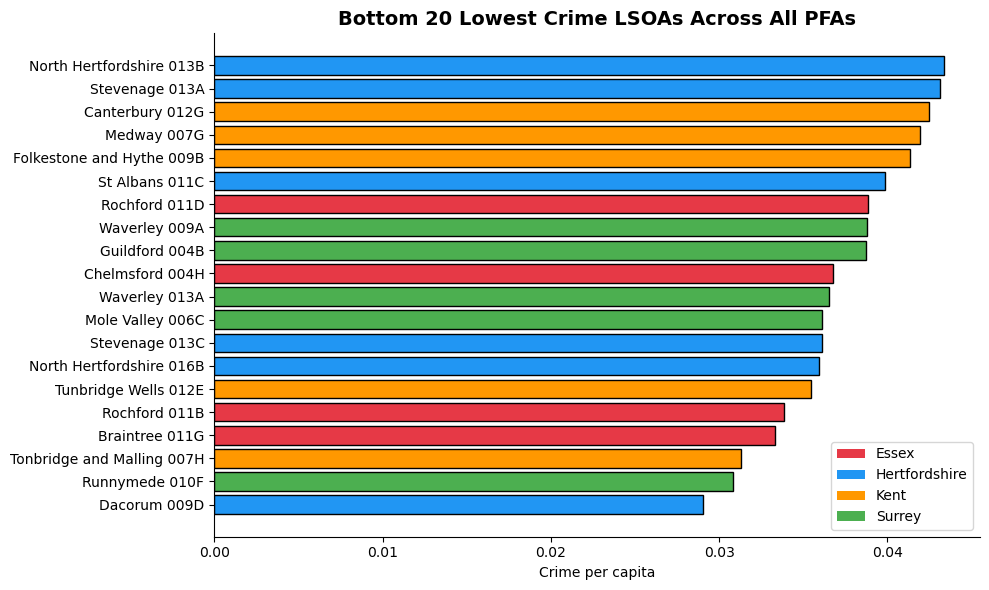

In [201]:
#Filtering out the outliers:
lsoa_avg = lsoa_avg[lsoa_avg['crime_pc'] > 0.01]

bot20_all = lsoa_avg.nsmallest(20, 'crime_pc').sort_values('crime_pc')

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors_list = [pfa_colors[pfa] for pfa in bot20_all['PFA']]

ax.barh(bot20_all['LSOA21NM'], bot20_all['crime_pc'],
        color=bar_colors_list, edgecolor='black')

ax.set_title('Bottom 20 Lowest Crime LSOAs Across All PFAs', fontsize=14, fontweight='bold')
ax.set_xlabel('Crime per capita')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=pfa_colors[pfa], label=pfa) for pfa in pfas]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## Which Police Force deals with the most crime per capita?

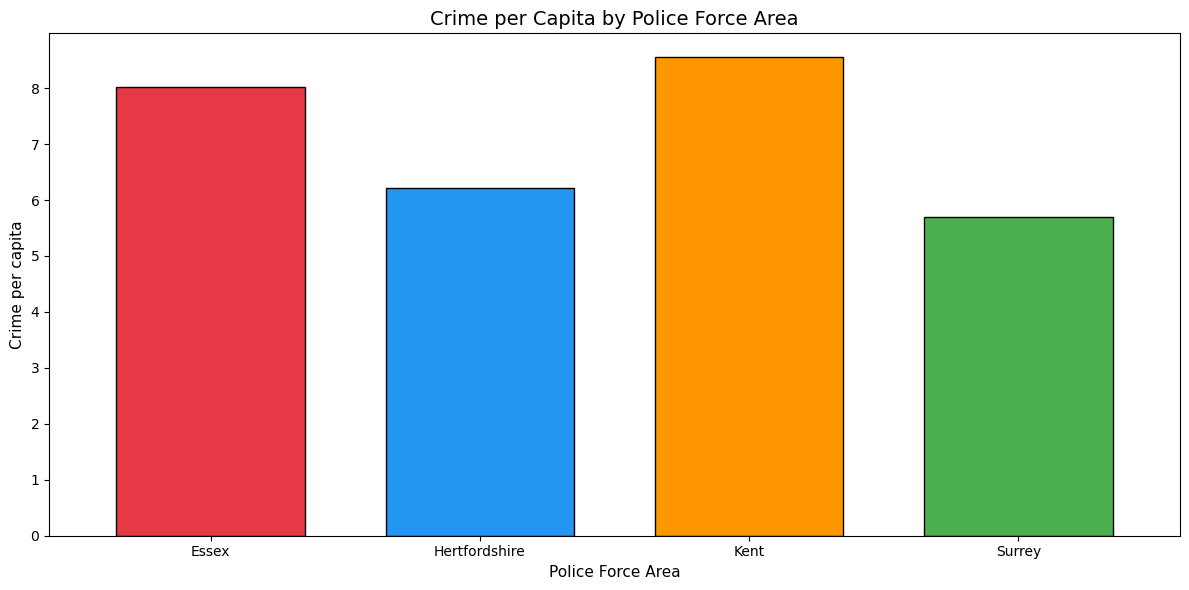

In [182]:
import matplotlib.pyplot as plt

#Population for each PFA for each year
pfa_pop = pfa_pop[pfa_pop['Year']!=2021]
pp22 = pfa_pop[pfa_pop['Year']==2022]
pp23 = pfa_pop[pfa_pop['Year']==2023]
pp24 = pfa_pop[pfa_pop['Year']==2024]

#Crime for each PFA for each year
forcesVS = forces[forces['Crime type']!='Anti-social behaviour']
forceGrouped = pd.DataFrame(forcesVS.groupby(['PFA','Year'])['Crime type'].count().rename('Crime volume'))
forceGrouped = forceGrouped.reset_index()
fg22 = forceGrouped[forceGrouped['Year']==2022]
fg23 = forceGrouped[forceGrouped['Year']==2023]
fg24 = forceGrouped[forceGrouped['Year']==2024]

#Merge both dataframes together
fp22 = fg22.merge(pp22[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp23 = fg23.merge(pp23[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp24 = fg24.merge(pp24[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')

#Concatenate each year together
force_pop = pd.concat([fp22,fp23,fp24])
force_pop = force_pop.reset_index(drop=True)

#Create column 'Per capita crime'
fig,ax = plt.subplots(figsize=(12,6))

force_pop = force_pop.groupby('PFA')[['Crime volume','Total']].sum()
cpc = force_pop['Crime volume']/force_pop['Total']*100
force_pop.insert(2,'Crime per capita',cpc)
bar_colors = [pfa_colors[pfa] for pfa in force_pop.index]
force_pop['Crime per capita'].plot(kind='bar',ax=ax,color=bar_colors,edgecolor='black',width=0.7)

ax.set_title('Crime per Capita by Police Force Area',fontsize=14)
ax.set_xlabel('Police Force Area', fontsize=11)
ax.set_ylabel('Crime per capita', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [199]:
for columns in forces_crime:
    print(columns)

PFA
Year
Anti-social behaviour
Bicycle theft
Burglary
Criminal damage and arson
Drugs
Other crime
Other theft
Possession of weapons
Public order
Robbery
Shoplifting
Theft from the person
Vehicle crime
Violence and sexual offences
PFA 2023 Name
Total


## Violence and sexual offences by PFA

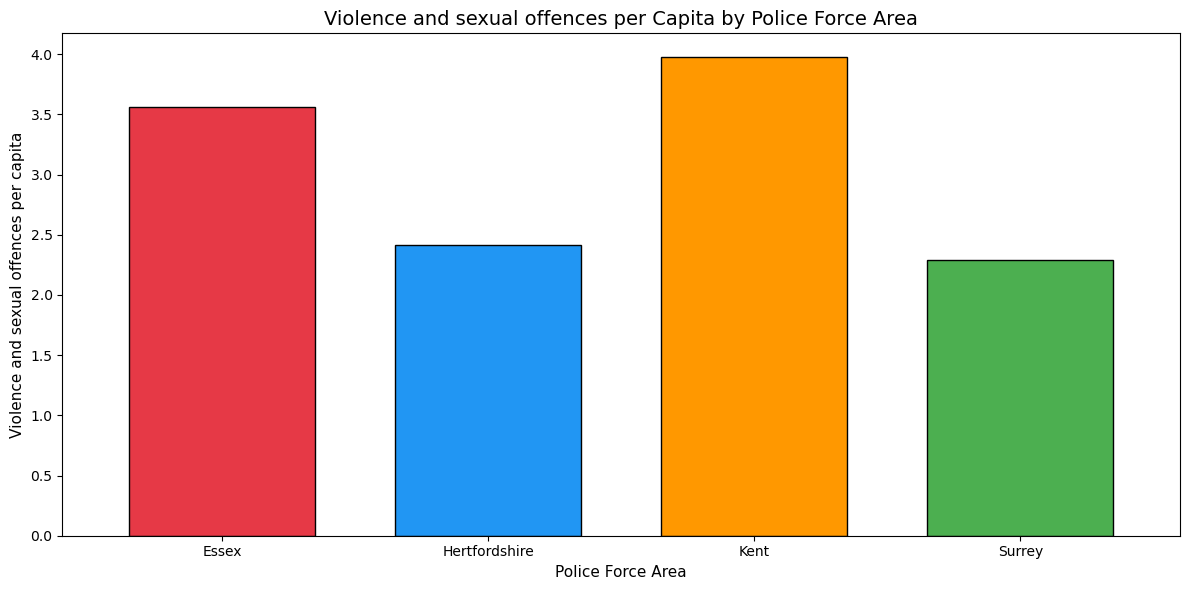

In [187]:
import matplotlib.pyplot as plt

#Population for each PFA for each year
pfa_pop = pfa_pop[pfa_pop['Year']!=2021]
pp22 = pfa_pop[pfa_pop['Year']==2022]
pp23 = pfa_pop[pfa_pop['Year']==2023]
pp24 = pfa_pop[pfa_pop['Year']==2024]

#Crime for each PFA for each year
forcesVS = forces[forces['Crime type']=='Violence and sexual offences']
forceGrouped = pd.DataFrame(forcesVS.groupby(['PFA','Year'])['Crime type'].count().rename('Crime volume'))
forceGrouped = forceGrouped.reset_index()
fg22 = forceGrouped[forceGrouped['Year']==2022]
fg23 = forceGrouped[forceGrouped['Year']==2023]
fg24 = forceGrouped[forceGrouped['Year']==2024]

#Merge both dataframes together
fp22 = fg22.merge(pp22[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp23 = fg23.merge(pp23[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp24 = fg24.merge(pp24[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')

#Concatenate each year together
force_pop = pd.concat([fp22,fp23,fp24])
force_pop = force_pop.reset_index(drop=True)

#Create column 'Per capita crime'
fig,ax = plt.subplots(figsize=(12,6))

force_pop = force_pop.groupby('PFA')[['Crime volume','Total']].sum()
cpc = force_pop['Crime volume']/force_pop['Total']*100
force_pop.insert(2,'Crime per capita',cpc)
bar_colors = [pfa_colors[pfa] for pfa in force_pop.index]
force_pop['Crime per capita'].plot(kind='bar',ax=ax,color=bar_colors,edgecolor='black',width=0.7)

ax.set_title('Violence and sexual offences per Capita by Police Force Area',fontsize=14)
ax.set_xlabel('Police Force Area', fontsize=11)
ax.set_ylabel('Violence and sexual offences per capita', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Burglary py PFA

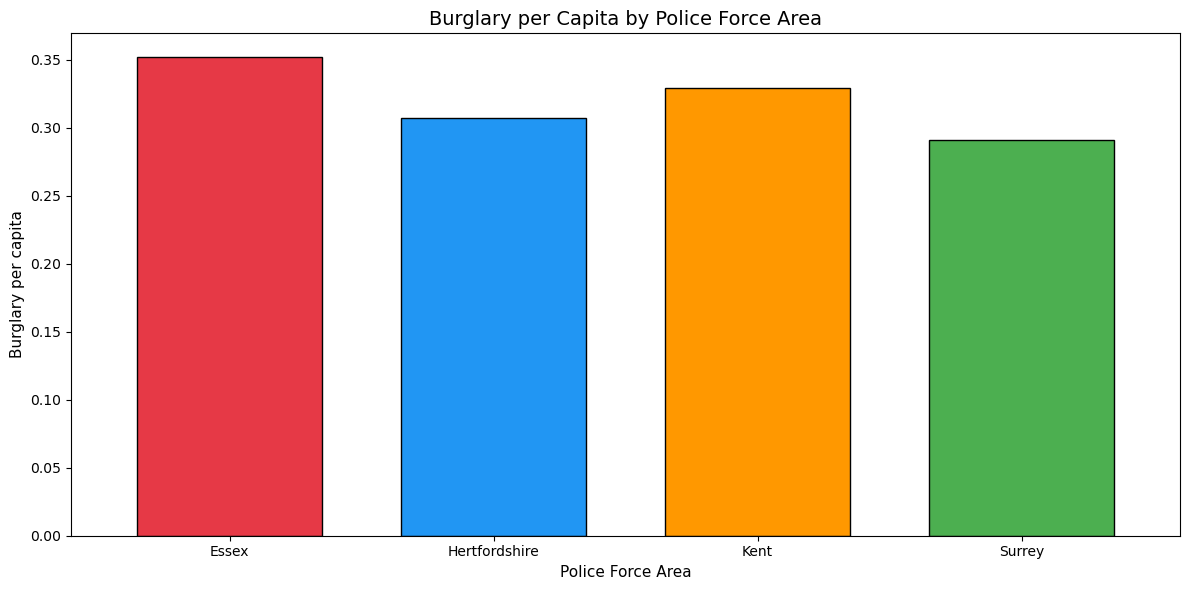

In [188]:
import matplotlib.pyplot as plt

#Population for each PFA for each year
pfa_pop = pfa_pop[pfa_pop['Year']!=2021]
pp22 = pfa_pop[pfa_pop['Year']==2022]
pp23 = pfa_pop[pfa_pop['Year']==2023]
pp24 = pfa_pop[pfa_pop['Year']==2024]

#Crime for each PFA for each year
forcesVS = forces[forces['Crime type']=='Burglary']
forceGrouped = pd.DataFrame(forcesVS.groupby(['PFA','Year'])['Crime type'].count().rename('Crime volume'))
forceGrouped = forceGrouped.reset_index()
fg22 = forceGrouped[forceGrouped['Year']==2022]
fg23 = forceGrouped[forceGrouped['Year']==2023]
fg24 = forceGrouped[forceGrouped['Year']==2024]

#Merge both dataframes together
fp22 = fg22.merge(pp22[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp23 = fg23.merge(pp23[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp24 = fg24.merge(pp24[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')

#Concatenate each year together
force_pop = pd.concat([fp22,fp23,fp24])
force_pop = force_pop.reset_index(drop=True)

#Create column 'Per capita crime'
fig,ax = plt.subplots(figsize=(12,6))

force_pop = force_pop.groupby('PFA')[['Crime volume','Total']].sum()
cpc = force_pop['Crime volume']/force_pop['Total']*100
force_pop.insert(2,'Crime per capita',cpc)
bar_colors = [pfa_colors[pfa] for pfa in force_pop.index]
force_pop['Crime per capita'].plot(kind='bar',ax=ax,color=bar_colors,edgecolor='black',width=0.7)

ax.set_title('Burglary per Capita by Police Force Area',fontsize=14)
ax.set_xlabel('Police Force Area', fontsize=11)
ax.set_ylabel('Burglary per capita', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Anti-Social Behaviour by PFA

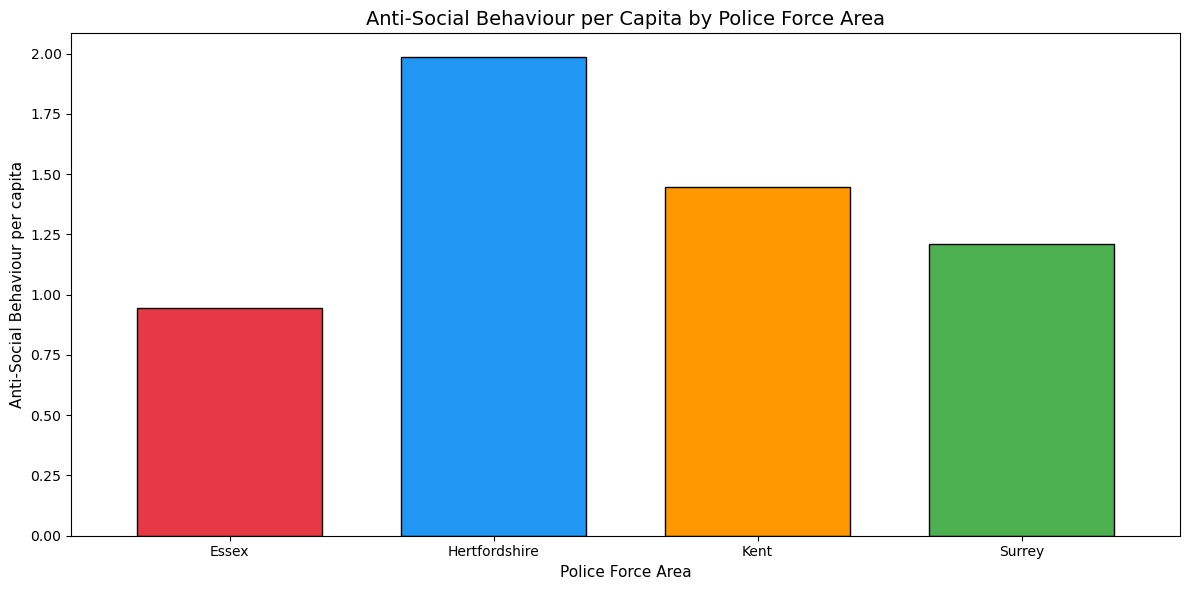

In [71]:
import matplotlib.pyplot as plt

#Population for each PFA for each year
pfa_pop = pfa_pop[pfa_pop['Year']!=2021]
pp22 = pfa_pop[pfa_pop['Year']==2022]
pp23 = pfa_pop[pfa_pop['Year']==2023]
pp24 = pfa_pop[pfa_pop['Year']==2024]

#Crime for each PFA for each year
forcesVS = forces[forces['Crime type']=='Anti-social behaviour']
forceGrouped = pd.DataFrame(forcesVS.groupby(['PFA','Year'])['Crime type'].count().rename('Crime volume'))
forceGrouped = forceGrouped.reset_index()
fg22 = forceGrouped[forceGrouped['Year']==2022]
fg23 = forceGrouped[forceGrouped['Year']==2023]
fg24 = forceGrouped[forceGrouped['Year']==2024]

#Merge both dataframes together
fp22 = fg22.merge(pp22[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp23 = fg23.merge(pp23[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')
fp24 = fg24.merge(pp24[['PFA 2023 Name','Total']],left_on='PFA',right_on='PFA 2023 Name',how='left')

#Concatenate each year together
force_pop = pd.concat([fp22,fp23,fp24])
force_pop = force_pop.reset_index(drop=True)

#Create column 'Per capita crime'
fig,ax = plt.subplots(figsize=(12,6))

force_pop = force_pop.groupby('PFA')[['Crime volume','Total']].sum()
cpc = force_pop['Crime volume']/force_pop['Total']*100
force_pop.insert(2,'Crime per capita',cpc)
bar_colors = [pfa_colors[pfa] for pfa in force_pop.index]
force_pop['Crime per capita'].plot(kind='bar',ax=ax,color=bar_colors,edgecolor='black',width=0.7)

ax.set_title('Anti-Social Behaviour per Capita by Police Force Area',fontsize=14)
ax.set_xlabel('Police Force Area', fontsize=11)
ax.set_ylabel('Anti-Social Behaviour per capita', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Violence and Sexual Offences by PFA Over Time

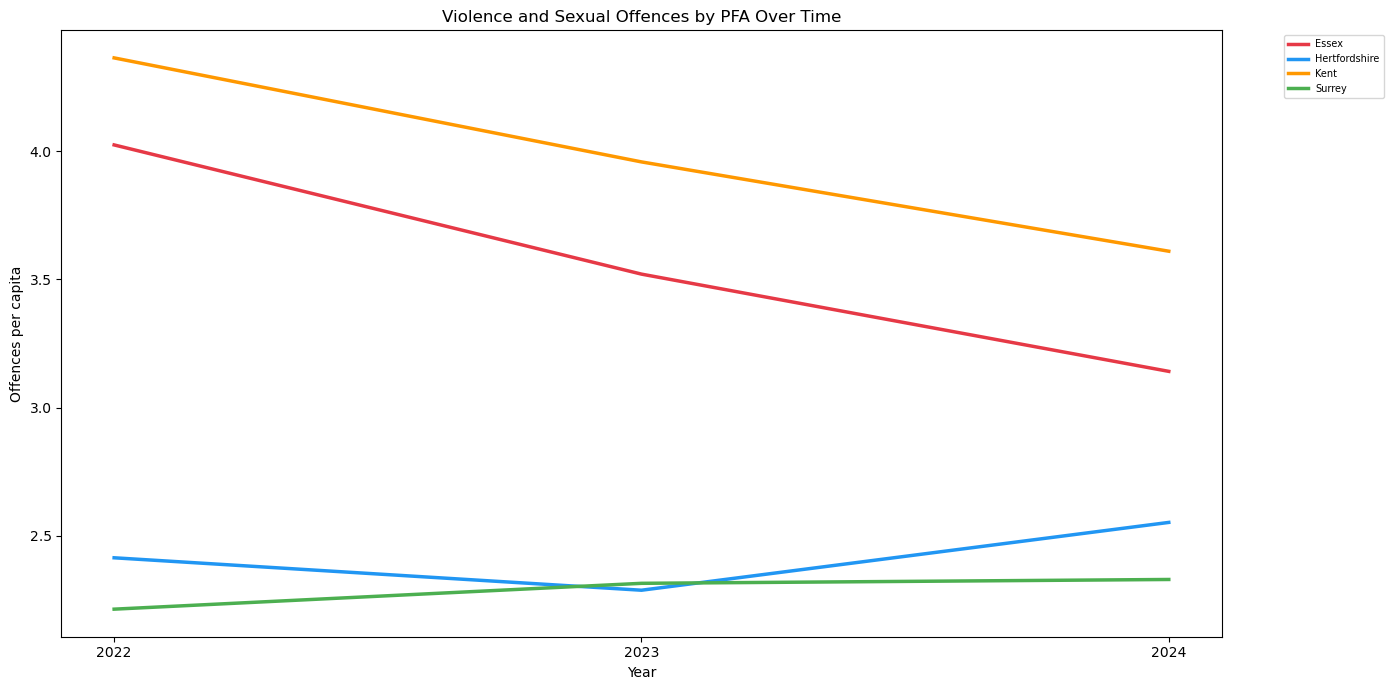

In [184]:
forces_crime = forces
forces_crime = pd.DataFrame(forces_crime.groupby(['PFA','Year','Crime type']).size().unstack(fill_value=0))

pfa_pop_1 = pd.DataFrame(pfa_pop.groupby(['PFA 2023 Name','Year'])['Total'].sum())

forces_crime = forces_crime.reset_index()
pfa_pop_1 = pfa_pop_1.reset_index()

forces_crime = forces_crime.merge(pfa_pop_1[['PFA 2023 Name','Year','Total']],left_on=['PFA','Year'],right_on=['PFA 2023 Name','Year'],how='left')

# Filter for Violence and sexual offences
violence_df = forces_crime[['PFA','Year','Violence and sexual offences','Total']]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for pfa, group in violence_df.groupby('PFA'):
    per_capita = group['Violence and sexual offences'] / group['Total'] *100
    ax.plot(group['Year'], per_capita, label=pfa,color=pfa_colors[pfa],linewidth=2.5)

ax.set_title('Violence and Sexual Offences by PFA Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Offences per capita')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)  # legend outside plot
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Burglary by PFA over time

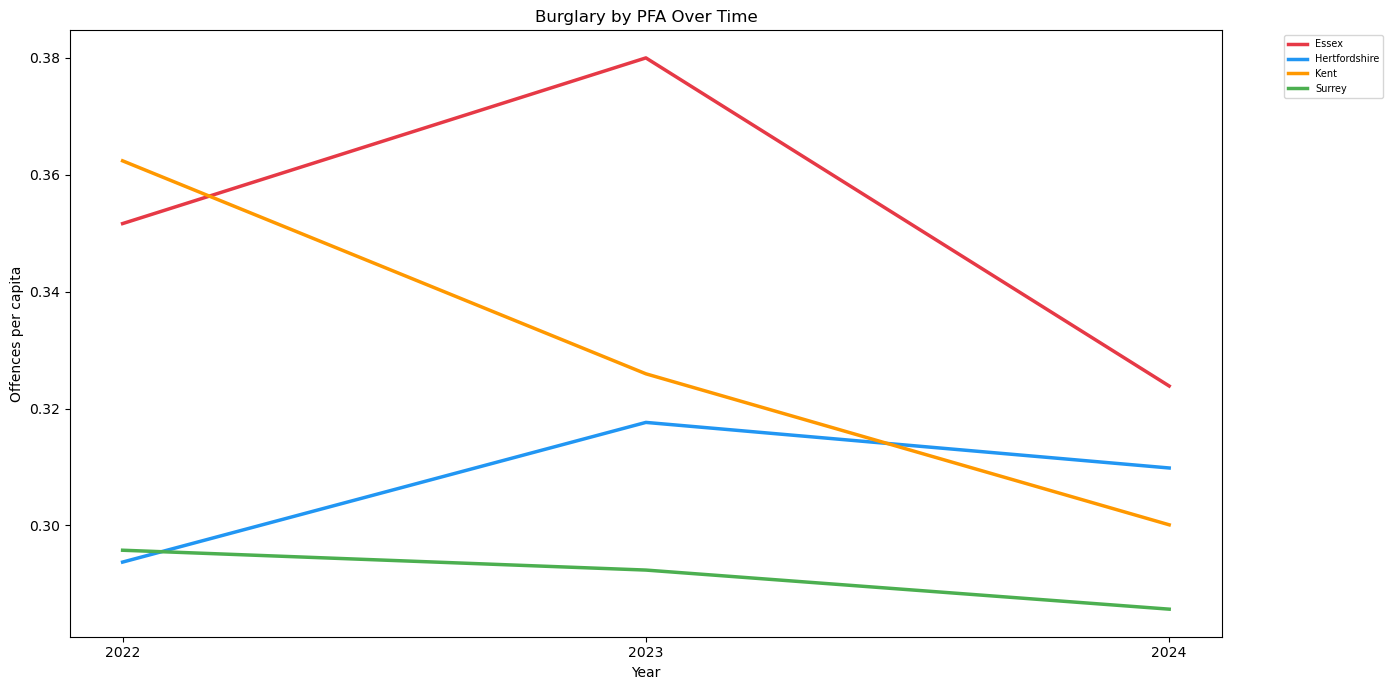

In [190]:
forces_crime = forces
forces_crime = pd.DataFrame(forces_crime.groupby(['PFA','Year','Crime type']).size().unstack(fill_value=0))

pfa_pop_1 = pd.DataFrame(pfa_pop.groupby(['PFA 2023 Name','Year'])['Total'].sum())

forces_crime = forces_crime.reset_index()
pfa_pop_1 = pfa_pop_1.reset_index()

forces_crime = forces_crime.merge(pfa_pop_1[['PFA 2023 Name','Year','Total']],left_on=['PFA','Year'],right_on=['PFA 2023 Name','Year'],how='left')

# Filter for Violence and sexual offences
violence_df = forces_crime[['PFA','Year','Burglary','Total']]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for pfa, group in violence_df.groupby('PFA'):
    per_capita = group['Burglary'] / group['Total'] *100
    ax.plot(group['Year'], per_capita, label=pfa,color=pfa_colors[pfa],linewidth=2.5)

ax.set_title('Burglary by PFA Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Offences per capita')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)  # legend outside plot
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Anti-social behaviour by PFA over time

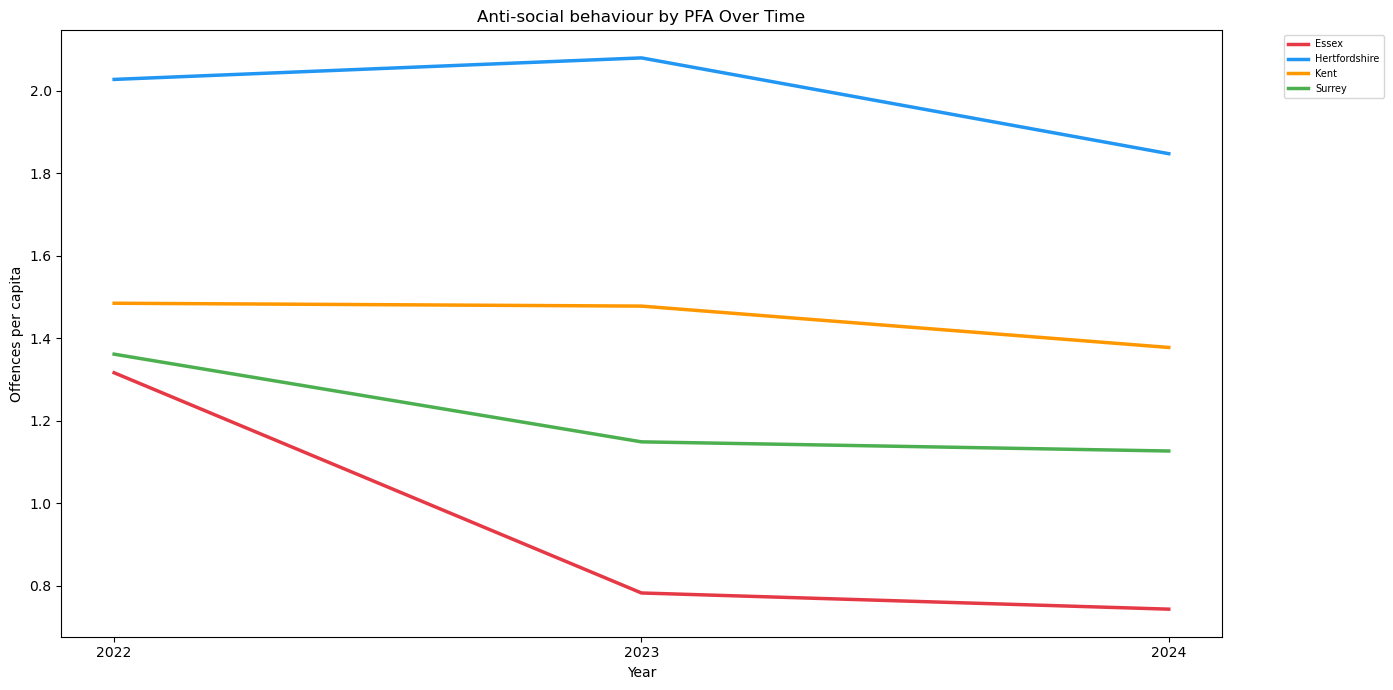

In [200]:
forces_crime = forces
forces_crime = pd.DataFrame(forces_crime.groupby(['PFA','Year','Crime type']).size().unstack(fill_value=0))

pfa_pop_1 = pd.DataFrame(pfa_pop.groupby(['PFA 2023 Name','Year'])['Total'].sum())

forces_crime = forces_crime.reset_index()
pfa_pop_1 = pfa_pop_1.reset_index()

forces_crime = forces_crime.merge(pfa_pop_1[['PFA 2023 Name','Year','Total']],left_on=['PFA','Year'],right_on=['PFA 2023 Name','Year'],how='left')

# Filter for Violence and sexual offences
violence_df = forces_crime[['PFA','Year','Anti-social behaviour','Total']]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for pfa, group in violence_df.groupby('PFA'):
    per_capita = group['Anti-social behaviour'] / group['Total'] *100
    ax.plot(group['Year'], per_capita, label=pfa,color=pfa_colors[pfa],linewidth=2.5)

ax.set_title('Anti-social behaviour by PFA Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Offences per capita')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)  # legend outside plot
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()